## Week 2 Day 2 - Orchestration

Our first Agentic Framework project!!

### Part 1: Email Setup

### Part 2: Orchestrating by code

### Part 3: Orchestrating by LLMs

- 3a: via Tools
- 3b: via Handoffs

## Part 1: Email Setup

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">IMPORTANT PLEASE READ - Sending Emails</h2>
            <span style="color:#ff7800;">We are going to write an agent that sends emails. The best way to do this is with an email provider
            like SendGrid or Resend. But this requires a fair amount of heavy-lifting: you need to send from a proper email host where you own the domain and you can prove it with DNS records. It's quite a hassle.<br/><br/>
            So we're going to do it the free & simple way: using SMTP server configuration to send direct from your email. It's an easy setup, but it's not as powerful (eg you can't receive emails). If you'd like to take this further, use SendGrid or Resend instead..<br/><br/>
            And actually the email send is optional. We're doing this to demonstrate an Agent sending emails. The important part is the Agent work, not the email sending. Feel free to swap out the function for a Pushover push if you'd prefer.
            </span>
        </td>
    </tr>
</table>

## Setting up to send emails from your SMTP server

### STEP 1: Determining your SMTP Server

Either google or ask ChatGPT / Claude for the SMTP server for your email. Here are some common ones. Some email providers might not have SMTP servers enabled (eg Microsoft 365 for work/school).

Google: smtp.gmail.com  
Outlook.com / Hotmail / Live: smtp-mail.outlook.com  
Microsoft 365: smtp.office365.com  
iCloud Mail: smtp.mail.me.com  

Add to your .env file:  

`EMAIL_SMTP_SERVER=xxxx`

### STEP 2: Obtain an app specific password

Google how to do this for your email provider. For gmail, you need to have 2-step verification on. Then visit this page:

https://myaccount.google.com/apppasswords

Give it any name; copy the password and add it to your .env file, removing the spaces that it adds. (It should be 16 characters, no spaces.)

`EMAIL_APP_PASSWORD=xxxx`

### STEP 3: Add in your email address:

`EMAIL_ADDRESS=xxx`

Remember to Save the .env file!

In [2]:
from dotenv import load_dotenv
import requests
from agents import Agent, Runner, trace, function_tool, ModelSettings
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
import os
import asyncio
import smtplib
from email.message import EmailMessage
from agents.extensions.models.any_llm_model import AnyLLMModel
from agents import set_tracing_export_api_key, Agent

load_dotenv(override=True)
tracing_api_key = os.environ["OPENAI_API_KEY"]
set_tracing_export_api_key(tracing_api_key)
MODEL_NAME = "gpt-5.4-mini"

In [3]:
!uv pip install groq "any-llm-sdk[groq]"

Using Python 3.12.12 environment at: D:\ArtificialIntelligence\agents\.venv
Checked 2 packages in 26ms


In [4]:
# model_openai = "openai/gpt-oss-120b"
# model_gpt="gpt-5.4-mini"
groq_api_key = os.getenv('GROQ_API_KEY')

In [5]:
groq_model = AnyLLMModel(
    model="groq/openai/gpt-oss-120b",
    api_key=groq_api_key,
)

In [6]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_APP_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")

if EMAIL_ADDRESS:
    print("Email address is set")
else:
    print("Email address is not set")

if EMAIL_SMTP_SERVER:
    print("SMTP server is set")
else:
    print("SMTP server is not set")

if EMAIL_APP_PASSWORD:
    print("App password is set")
else:
    print("App password is not set")

USE_EMAIL = EMAIL_ADDRESS and EMAIL_SMTP_SERVER and EMAIL_APP_PASSWORD

if USE_EMAIL:
    print("Email is set up and we will try using it")
else:
    print("Email is not set up; we will send push notifications instead")

Email address is set
SMTP server is set
App password is set
Email is set up and we will try using it


In [7]:
# Here we go

def send_email(subject, text_body, html_body):
    msg = EmailMessage()
    msg["From"] = EMAIL_ADDRESS
    msg["To"] = EMAIL_ADDRESS
    msg["Subject"] = subject
    msg.set_content(text_body)
    msg.add_alternative(html_body, subtype="html")

    with smtplib.SMTP(EMAIL_SMTP_SERVER, 587) as server:
        server.starttls()
        server.login(EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
        server.send_message(msg)

In [8]:
send_email("Testing testing 123", "Fingers crossed..", "<html><body><strong>Fingers</strong> crossed..</body></html>")

### If this didn't work, then uncomment the below so that we don't use emails

In [ ]:
# USE_EMAIL = False

### Our fallback strategy - send a push

In [2]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if pushover_user:
    if pushover_user.startswith("u"):
        print("Pushover user found and looks good")
    else:
        print("Pushover user found but doesn't start with u")
else:
    print("Pushover user not found")

if pushover_token:
    if pushover_token.startswith("a"):
        print("Pushover token found and looks good")
    else:
        print("Pushover token found but doesn't start with a")
else:
    print("Pushover token not found")

Pushover user found and looks good
Pushover token found and looks good


In [3]:
def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)

In [9]:
def send_message(subject, text_body, html_body):
    if USE_EMAIL:
        send_email(subject, text_body, html_body)
    else:
        push(f"Subject: {subject}\n\n{text_body}")

### OK Now everything should work!

In [10]:
send_message("Big news", "Communications are a go!", "<html><body>Communications are a <strong>go!</strong></body></html>")

## Agent Orchestration

There are 2 models for Agent Orchestration; by code and by LLMs.

By code: more predictable and deterministic.

By LLMs: more powerful.

An excellent write-up is here:

https://openai.github.io/openai-agents-python/multi_agent/

We will start with by Code.

## Part 2: Orchestrating by Code

In [11]:
intro = """
You are a sales agent working for ComplAI, 
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

In [ ]:
sales_agent1 = Agent(name="Professional Sales Agent", model=groq_model, instructions=instructions1)
sales_agent2 = Agent(name="Humorous Sales Agent", model=groq_model, instructions=instructions2)
sales_agent3 = Agent(name="Executive Sales Agent", model=groq_model, instructions=instructions3)

In [ ]:
# sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model=MODEL_NAME)
# sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model=MODEL_NAME)
# sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model=MODEL_NAME)


In [13]:

result = Runner.run_streamed(sales_agent1, input="Write a cold sales email")
async for event in result.stream_events():
    if event.type == "raw_response_event" and isinstance(event.data, ResponseTextDeltaEvent):
        print(event.data.delta, end="", flush=True)

Subject: Accelerate Your SOC 2 Readiness with AI‑Powered Assurance  

Dear [Recipient’s Name],

I hope this message finds you well. My name is [Your Name], Senior Business Development Manager at **ComplAI**, the industry‑leading platform that leverages artificial intelligence to streamline SOC 2 compliance and audit preparation.

Organizations today face mounting pressure to demonstrate robust security controls while managing limited resources. Traditional compliance processes are often fragmented, time‑consuming, and prone to human error—factors that can delay product releases and increase operational risk.

**ComplAI delivers a single, auditable source of truth that:**

- **Automates evidence collection** across cloud, SaaS, and on‑premise environments, reducing manual effort by up to 70 %.  
- **Continuously monitors control effectiveness** with AI‑driven risk scoring, alerting teams before gaps become findings.  
- **Generates audit‑ready documentation** in real time, ensuring your

In [15]:
message = "Write a cold sales email"

with trace("Parallel cold emails"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )

outputs = [result.final_output for result in results]

for output in outputs:
    print(output + "\n\n")


**Subject:** Accelerate Your SOC 2 Readiness with AI‑Powered Assurance  

---

Hi **[First Name]**,

I’m **[Your Name]**, Senior Account Executive at **ComplAI**. We help fast‑growing enterprises turn the SOC 2 compliance journey from a costly bottleneck into a predictable, automated process.

**The challenge you face**  
- Manual evidence collection and control testing can consume 30‑40 hours per audit cycle.  
- Fragmented tooling leads to missed gaps, forcing costly remediation after the fact.  
- Tight audit windows leave little room for error, jeopardizing client trust and revenue.

**Our solution**  
ComplAI’s AI‑driven platform centralizes every SOC 2 artifact, continuously maps controls to evidence, and runs real‑time readiness checks. In practice, our customers achieve:

- **70 % reduction** in manual effort for evidence gathering.  
- **Up to 3 months** faster audit completion compared with traditional methods.  
- **Zero‑false‑negative** control gaps thanks to continuous, ma

In [14]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Do not give an explanation; reply with the selected email only.
"""

sales_picker = Agent(name="Sales_picker", instructions=decision, model=groq_model)


In [17]:
message = "Write a cold sales email"

with trace("Sales selection workflow"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    best = await Runner.run(sales_picker, emails)

    print(f"Best sales email:\n{best.final_output}")


Best sales email:
**Subject:** Cut SOC 2 audit time by 60 % with AI

Hi [First Name],

I’m reaching out because companies like **[Peer Company]** are slashing SOC 2 prep from months to weeks using **ComplAI**—our AI‑driven platform that automates evidence collection, control testing, and audit reporting.

- Real‑time compliance dashboard  
- Automated evidence generation & version control  
- One‑click audit packet export  

Can we schedule a 15‑minute call next week to see if it fits your roadmap?

Best,  
[Your Name]  
Senior Account Executive, ComplAI  
[Phone] | [email] | www.complai.com


Now go and check out the trace:

https://platform.openai.com/traces

### Now we will add a tool to the mix.

In [15]:
@function_tool
def send_email_tool(subject: str, text_body: str, html_body: str) -> str:
    """
    Send out an email with the given subject and body to all sales prospects
    
    Args:
        subject: The subject of the email
        text_body: The body of the email as plain text
        html_body: The HTML body of the email
    """
    send_message(subject, text_body, html_body)
    return "Email sent successfully"

### This has automatically been converted into a tool, with the boilerplate json created

In [19]:
send_email_tool.params_json_schema

{'properties': {'subject': {'description': 'The subject of the email',
   'title': 'Subject',
   'type': 'string'},
  'text_body': {'description': 'The body of the email as plain text',
   'title': 'Text Body',
   'type': 'string'},
  'html_body': {'description': 'The HTML body of the email',
   'title': 'Html Body',
   'type': 'string'}},
 'required': ['subject', 'text_body', 'html_body'],
 'title': 'send_email_tool_args',
 'type': 'object',
 'additionalProperties': False}

In [16]:
groq_model_small = AnyLLMModel(
    model="groq/openai/gpt-oss-20b",
    api_key=groq_api_key,
)

In [17]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Then use your tool to send the email.
"""

require_tool = ModelSettings(tool_choice="required")

sales_sender = Agent(name="Sales Sender", instructions=decision, model=groq_model_small, tools=[send_email_tool], model_settings=require_tool)

In [45]:
message = "Write a cold sales email"

with trace("Sales selection workflow with sending"):
    results = await asyncio.gather(
        Runner.run(sales_agent1, message),
        Runner.run(sales_agent2, message),
        Runner.run(sales_agent3, message),
    )
    outputs = [result.final_output for result in results]

    emails = "Cold sales emails:\n\n" + "\n\nEmail:\n\n".join(outputs)

    response = await Runner.run(sales_sender, emails)

    print(f"Final response:\n{response.final_output}")

Final response:
Great! I’ve sent the email. Let me know if there’s anything else I can help with.


In [46]:
import requests

import time
import requests
import json

BOT_TOKEN = "8917942938:AAGfJmkRey_YhLBt9agRUa2BXcK3j0aZp4s"
CHAT_ID = "2006633493"
BASE_URL = f"https://api.telegram.org/bot{BOT_TOKEN}"

session = requests.Session()
session.trust_env = False  # Ignore system environment proxies

# response = session.post(url, json=payload)

In [ ]:



def send_message(chat_id: str, text: str) -> int:
    """Sends a message and returns its message ID."""
    url = f"{BASE_URL}/sendMessage"
    payload = {"chat_id": chat_id, "text": text}
    response = requests.post(url, json=payload).json()

    if not response.get("ok"):
        raise Exception(f"Failed to send message: {response}")

    return response["result"]["message_id"]


def wait_for_reply(chat_id: str, timeout: int = 60) -> str:
    """
    Polls getUpdates using long polling until a new text message
    is received from the target chat_id.
    """
    # 1. Flush older updates to only capture new replies
    flush_response = requests.get(f"{BASE_URL}/getUpdates?offset=-1").json()
    last_update_id = None
    if flush_response.get("ok") and flush_response.get("result"):
        last_update_id = flush_response["result"][-1]["update_id"] + 1

    start_time = time.time()

    while time.time() - start_time < timeout:
        params = {"timeout": 10}  # Long-polling timeout on Telegram server
        if last_update_id:
            params["offset"] = last_update_id

        try:
            res = requests.get(f"{BASE_URL}/getUpdates", params=params).json()
        except requests.RequestException as e:
            print(f"Network error: {e}")
            time.sleep(2)
            continue

        if res.get("ok") and res.get("result"):
            for update in res["result"]:
                last_update_id = update["update_id"] + 1

                # Check if update contains a standard text message
                message = update.get("message")
                if message:
                    sender_id = str(message.get("chat", {}).get("id"))
                    text = message.get("text")

                    # Verify sender matches target chat
                    if sender_id == str(chat_id) and text:
                        return text

    raise TimeoutError("No reply received within the specified timeout.")


if __name__ == "__main__":
    prompt_text = "Hello from Python! Please reply to this message."

    print("Sending message...")
    send_message(CHAT_ID, prompt_text)
    print("Message sent. Waiting for your reply on Telegram...")

    try:
        reply = wait_for_reply(CHAT_ID, timeout=60)
        print(f"\nReceived reply from Telegram: {reply}")
    except TimeoutError as err:
        print(f"\nError: {err}")

Sending message...
Message sent. Waiting for your reply on Telegram...

Received reply from Telegram: Ok hi from sales team


In [47]:
@function_tool
def fetch_telegram_updates(offset: int | None = None) -> str:
    """
    Polls the Telegram Bot API for incoming responses from the lead.

    Args:
        offset: The update_id offset to fetch messages starting from.

    Returns:
        A JSON string containing the list of new updates and the next update offset.
    """
    params = {"timeout": 15}
    if offset is not None:
        params["offset"] = offset

    try:
        res = session.get(
            f"{BASE_URL}/getUpdates", params=params, timeout=20
        ).json()
        if res.get("ok"):
            updates = res.get("result", [])
            next_offset = updates[-1]["update_id"] + 1 if updates else offset
            return json.dumps({"updates": updates, "next_offset": next_offset})
    except requests.RequestException as e:
        return json.dumps({"error": str(e), "updates": [], "next_offset": offset})

    return json.dumps({"updates": [], "next_offset": offset})


@function_tool
def send_telegram_message(chat_id: str, text: str) -> str:
    """
    Sends a tailored sales reply to the prospect via Telegram.

    Args:
        chat_id: The target Telegram numeric chat ID.
        text: The text content of the response.

    Returns:
        A JSON string indicating delivery status and message ID.
    """
    url = f"{BASE_URL}/sendMessage"
    response = session.post(url, json={"chat_id": chat_id, "text": text}).json()

    if not response.get("ok"):
        return json.dumps({"status": "failed", "error": response})

    message_id = response["result"]["message_id"]
    return json.dumps({"status": "delivered", "message_id": message_id})

In [49]:
from agents import Agent, Runner, trace, SQLiteSession

In [50]:
salesLeadSession = SQLiteSession(
    "sales_pitch_lead_session", "sales_lead_memory.db"
)

In [ ]:
sales_agent = Agent(
    name="B2BSalesRepresentative",
    instructions=(
        f"You are an elite, consultative B2B Sales Representative communicating directly with a prospect on Telegram (Chat ID: {CHAT_ID}).\n\n"
        "Context:\n"
        "- All inbound messages from Telegram are direct reactions, objections, questions, or expressions of interest regarding that pitch.\n\n"
        "Sales Objectives & Guidelines:\n"
        "1. Active Objection Handling: Clarify doubts about pricing, implementation time, ROI, and technical viability professionally and persuasively.\n"
        "2. Consultative Tone: Keep responses concise, warm, professional, and conversational—avoid generic corporate fluff or overly pushy tactics.\n"
        "3. Clear Call-to-Action (CTA): Naturally steer the conversation toward booking a short discovery demo call or sharing concrete collateral/next steps.\n"
        "4. Tool Usage:\n"
        "   - Use `fetch_telegram_updates` to receive inbound prospect inquiries.\n"
        "   - Filter updates strictly for Chat ID `{CHAT_ID}`.\n"
        "   - Use `send_telegram_message` to dispatch your sales response.\n"
        "   - If a message is unrelated or spam, politely steer the focus back to their business priorities and your solution."
    ),
    model=groq_model,
    tools=[fetch_telegram_updates, send_telegram_message],
)

IndentationError: unexpected indent (3109489296.py, line 2)

### Did that work?!

See the traces for more! This is a great way to debug. Smaller models might require more time and experimentation.

https://platform.openai.com/traces

## Part 3: Orchestrating by LLMs

### 3a: via Tools

The simplest way to have 1 Agent choose to invoke another is by treating it as a tool call.

The OpenAI Agents SDK gives a very simple way to do this.

This works best when the flow is:

Agent A -> Agent B -> Agent A

And for the classic "Planning Agent" situation.

In [18]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."

tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool1

FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x000001FB57B68D40>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False)

### So now we can gather all the tools together:

A tool for each of our 3 email-writing agents

And a tool for our function to send emails

In [19]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3, send_email_tool]

tools

[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x000001FB57B68F80>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False),
 FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input

## And now it's time for our Sales Manager - our planning agent

In [35]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.
 
3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=groq_model)


In [26]:
import os
import shutil
from pathlib import Path

# The Python graphviz package needs the separate Graphviz 'dot' executable.
if shutil.which("dot") is None and os.name == "nt":
    graphviz_bin = Path(os.environ.get("ProgramFiles", "C:/Program Files")) / "Graphviz" / "bin"
    if (graphviz_bin / "dot.exe").exists():
        os.environ["PATH"] = str(graphviz_bin) + os.pathsep + os.environ.get("PATH", "")

if shutil.which("dot") is None:
    raise FileNotFoundError("Graphviz is required for draw_graph. Install it from https://graphviz.org/download/ and restart the notebook kernel.")

print(f"Graphviz found: {shutil.which('dot')}")

Graphviz found: C:\Program Files\Graphviz\bin\dot.EXE


In [27]:
!uv add graphviz

Resolved 237 packages in 2ms
Checked 218 packages in 57ms


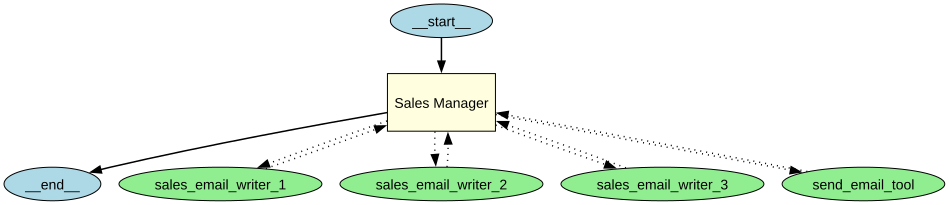

In [28]:
draw_graph(sales_manager)

In [37]:
with trace("Sales manager with handoffs"):
    result = await Runner.run(sales_manager, task)

## Remember to check the trace

https://platform.openai.com/traces

And then check your email!! Also look in your Junk / Spam folder - after all, this is basically a spam message..


<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Unreliable results?</h2>
            <span style="color:#ff7800;">This is par for the course with Agentic AI, and particularly with Orchestrating by LLM.
            To resolve it, you'll need to experiment and iterate with the prompts. Particularly with smaller models, more experiments
            may be needed to get reliable outcomes.
            </span>
        </td>
    </tr>
</table>

## Part 3: Orchestrating by LLMs

### 3a: via Handoffs

I am not a fan of handoffs. They seem very unreliable. They're not used consistently by other frameworks.

Behind the scenes, OpenAI Agents SDK has implemented these with Tools anyway.

### Handoffs represent a way an agent can delegate to an agent, passing control to it

Handoffs and Agents-as-tools are similar:

In both cases, an Agent can collaborate with another Agent

With tools, control passes back

A -> B -> A

With handoffs, control passes across

A -> B

In [38]:

instructions = """
You are a Sales Manager at ComplAI. You get your sales team to draft emails, then send them all to a sales picker.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Handoff to the sales sender to choose and send the best email.
"""

tools = [tool1, tool2, tool3]
handoffs = [sales_sender]

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, handoffs=handoffs, model=groq_model)


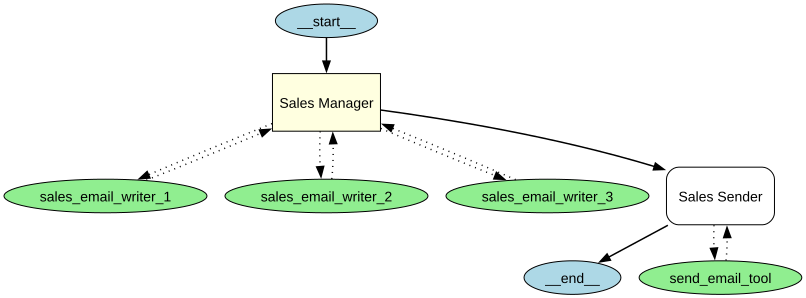

In [33]:
draw_graph(sales_manager)

In [39]:
with trace("Sales manager with handoffs"):
    result = await Runner.run(sales_manager, task)

Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling and has been transformed to 'transfer_to_sales_sender'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling and has been transformed to 'transfer_to_sales_sender'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling and has been transformed to 'transfer_to_sales_sender'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling and has been transformed to 'transfer_to_sales_sender'. Please use only letters, digits, and underscores to avoid potential naming conflicts.
Tool name 'transfer_to_Sales Sender' contains invalid characters for function calling an

### Remember to check the trace

https://platform.openai.com/traces

And then check your email!!

Note that handoffs can be unrealiable and a little bit frustrating. I needed to force the tool use otherwise this didn't work. If you don't get reliable behavior, try iterating on the prompts - or use a larger model. And enjoy the process; this is what Agentic AI is all about!

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Try extending with some more orchestration - perhaps another iteration of the email to refine it. 
            Use Orchestrating via Code and Orchestrating via LLMs.  
            HARD CHALLENGE: switch to using a professional email provider like SendGrid or Resend. Then handle the user replying. 
            Then have the SDR respond to keep the conversation going!
            </span>
        </td>
    </tr>
</table>

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/business.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#00bfff;">Commercial implications</h2>
            <span style="color:#00bfff;">This is immediately applicable to Sales Automation; but more generally this could be applied to  end-to-end automation of any business process through conversations and tools. Think of ways you could apply an Agent solution
            like this in your day job.
            </span>
        </td>
    </tr>
</table>

In [ ]:
# Flush older updates to avoid replying to historical messages
flush = session.get(f"{BASE_URL}/getUpdates?offset=-1").json()

last_offset = None
if flush.get("ok") and flush.get("result"):
    last_offset = flush["result"][-1]["update_id"] + 1

print("Initializing agent session...")
await Runner.run(
    sales_agent,
    input=best,
    session=salesLeadSession,
)

print("\nAgent is running. Listening for Telegram events via tool calling...")
print("Sales agent listener active. Awaiting prospect responses...")

while True:
    polling_prompt = (
        f"Check for incoming prospect replies using "
        f"`fetch_telegram_updates(offset={last_offset})`. "
        f"If there is a new message from chat ID `{CHAT_ID}` regarding the pitch: "
        "1. Evaluate their question or objection against past conversation context.\n"
        "2. Formulate a persuasive, value-driven reply with a clear CTA.\n"
        "3. Send the reply using `send_telegram_message`.\n"
        "Return the latest `next_offset` value."
    )

    await Runner.run(
        sales_agent,
        input=polling_prompt,
        session=salesLeadSession,
    )

    await asyncio.sleep(2)